In [ ]:
"""
間隔が電圧比例に拡大するなら、データ同士のx座標（すなわちchannel)は、x' = a x の関係にあるべき。
すなわち、log x' = log a + log x
横軸をlogとれば、広がりが並進移動に変換される。
しかし、異なるデータを実際log軸で比較すると、明らかに並進移動のみならず、広がりも変化している。
"""

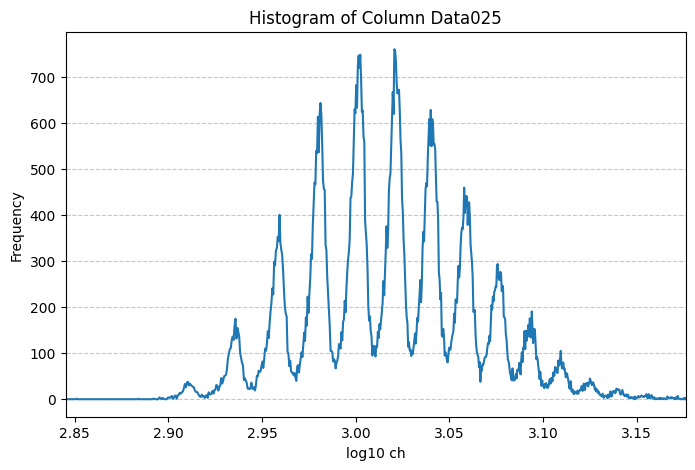

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# 1. txtファイルの読み込み（スペース区切りの場合: sep=r'\s+'、カンマ区切りの場合: sep=','）
# header=None はファイルに列名（ヘッダー）が含まれていない場合に設定します
df = pd.read_csv("summer025_ADC_HIGH_7.txt", sep=r'\s+', header=None)
channels = df[0]
counts = df[1]

logch = np.log10(channels)

plt.figure(figsize=(8, 5))
plt.plot(logch,df[1])
plt.xlim(np.log10(700),np.log10(1500))
# グラフの装飾

plt.title("Histogram of Column Data025")
plt.xlabel("log10 ch")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 表示
plt.show()



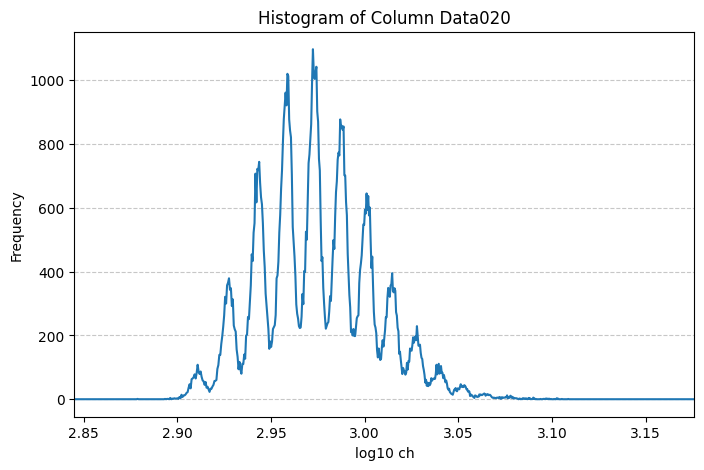

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# 1. txtファイルの読み込み（スペース区切りの場合: sep=r'\s+'、カンマ区切りの場合: sep=','）
# header=None はファイルに列名（ヘッダー）が含まれていない場合に設定します
df = pd.read_csv("summer020_ADC_HIGH_7.txt", sep=r'\s+', header=None)
channels = df[0]
counts = df[1]

logch = np.log10(channels)

plt.figure(figsize=(8, 5))
plt.plot(logch,df[1])
plt.xlim(np.log10(700),np.log10(1500))
# グラフの装飾

plt.title("Histogram of Column Data020")
plt.xlabel("log10 ch")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 表示
plt.show()



    data_num   max_x  log10_max_x   max_y
0         11   814.5     2.910891  7158.0
1         12   818.5     2.913019  5653.0
2         13   826.5     2.917243  3423.0
3         14   838.5     2.923503  2316.0
4         15   846.5     2.927627  1894.0
5         16   870.5     2.939769  1589.0
6         17   878.5     2.943742  1362.0
7         18   890.5     2.949634  1331.0
8         19   898.5     2.953518  1159.0
9         20   938.5     2.972434  1097.0
10        21   954.5     2.979776  1056.0
11        22   965.5     2.984752   976.0
12        23   978.5     2.990561   919.0
13        24   990.5     2.995854   806.0
14        25  1048.5     3.020568   761.0


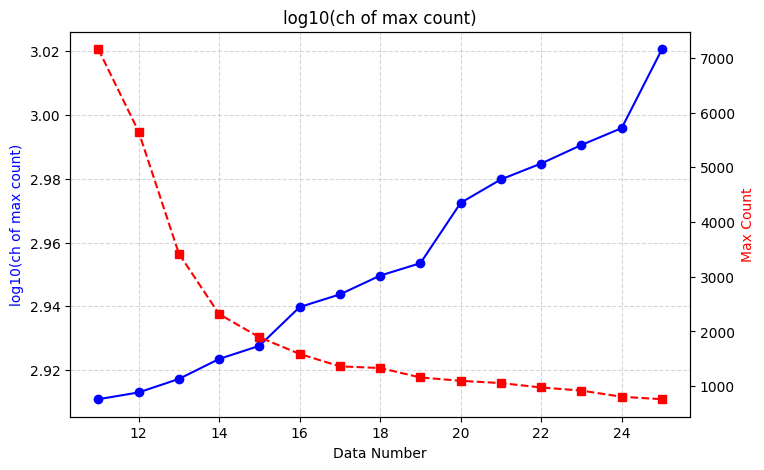

In [47]:
import glob
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 該当するtxtファイルをすべて検索してソート
file_list = sorted(glob.glob("summer*_ADC_HIGH_7.txt"))

results = []

for filepath in file_list:
    # ファイル名からデータ番号（例: summer011 -> 11）を抽出
    match = re.search(r"summer(\d+)", filepath)
    data_num = int(match.group(1)) if match else filepath

    # データ読み込み
    df = pd.read_csv(filepath, sep=r"\s+", header=None)

    # y (カウント数: 列1) が最大となる行のインデックスを取得
    max_idx = df[1].idxmax()
    max_y = df[1].iloc[max_idx]
    max_x = df[0].iloc[max_idx]
    log10_max_x = np.log10(max_x)

    results.append(
        {
            "data_num": data_num,
            "max_x": max_x,
            "log10_max_x": log10_max_x,
            "max_y": max_y,
            "file": filepath,
        }
    )

# 結果をDataFrameにまとめる
res_df = pd.DataFrame(results)
print(res_df[["data_num", "max_x", "log10_max_x", "max_y"]])

# --- 比較プロット ---
fig, ax1 = plt.subplots(figsize=(8, 5))

# データ番号 vs ピーク位置 log10(x)
ax1.plot(
    res_df["data_num"], res_df["log10_max_x"], "o-b", label="log10(Peak x)"
)
ax1.set_xlabel("Data Number")
ax1.set_ylabel("log10(ch of max count)", color="b")
ax1.grid(True, linestyle="--", alpha=0.5)

# データ番号 vs ピークの高さ (y最大値) を右軸に表示
ax2 = ax1.twinx()
ax2.plot(res_df["data_num"], res_df["max_y"], "s--r", label="Max Count")
ax2.set_ylabel("Max Count", color="r")

plt.title("log10(ch of max count)")
plt.show()

In [43]:
"""
それぞれのデータの最大値のlog10(ch)を並べると、このようになった。
直線だと信じれば
x' = exp(b) * x ^ a
log x' = a(V) log x + b
の関係にある。

また、maxcountが指数関数的に減少することからも、横幅が指数関数的に増加することを示唆する。
"""

"\n直線だと信じれば\nx' = exp(b) * x ^ a\nlog x' = a log x + b\n"

直線モデル (Linear)      RMSE: 9.8988
指数関数モデル (Exp)      RMSE: 3.4924


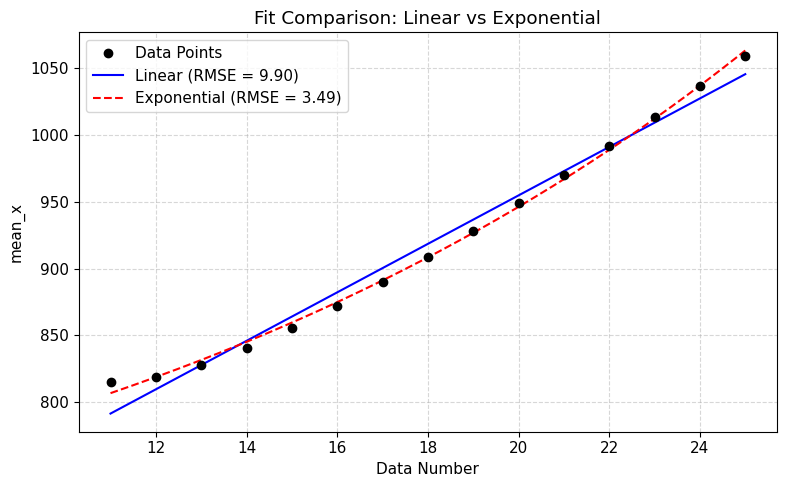

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# --- 1. データ準備 ---
valid_df = res_df.dropna(subset=["mean_x"]).sort_values("data_num")
x_data = valid_df["data_num"].values
y_data = valid_df["mean_x"].values


# --- 2. モデル定義 & フィッティング ---
def linear_model(x, a, b):
    return a * x + b


def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c


# 直線フィット
popt_lin, _ = curve_fit(linear_model, x_data, y_data)
y_pred_lin = linear_model(x_data, *popt_lin)

# 指数関数フィット
popt_exp, _ = curve_fit(exp_model, x_data, y_data, p0=[100, 0.01, 500])
y_pred_exp = exp_model(x_data, *popt_exp)

# --- 3. 平均平方残差 (RMSE) の計算 ---
rmse_lin = np.sqrt(np.mean((y_data - y_pred_lin) ** 2))
rmse_exp = np.sqrt(np.mean((y_data - y_pred_exp) ** 2))

# 結果の表示
print(f"直線モデル (Linear)      RMSE: {rmse_lin:.4f}")
print(f"指数関数モデル (Exp)      RMSE: {rmse_exp:.4f}")

# --- 4. フィットプロット ---
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)

plt.figure(figsize=(8, 5))
plt.plot(
    x_data, y_data, "ko", label="Data Points", zorder=3
)  # 測定データ (黒点)
plt.plot(
    x_smooth,
    linear_model(x_smooth, *popt_lin),
    "b-",
    label=f"Linear (RMSE = {rmse_lin:.2f})",
)
plt.plot(
    x_smooth,
    exp_model(x_smooth, *popt_exp),
    "r--",
    label=f"Exponential (RMSE = {rmse_exp:.2f})",
)

plt.xlabel("Data Number")
plt.ylabel("mean_x")
plt.title("Fit Comparison: Linear vs Exponential")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()